In [1]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from pathlib import Path
project_root = Path().resolve().parent

In [2]:
df_full = pd.read_csv(project_root / "data/cleaned.csv")

non_str = df_full.select_dtypes(include=["number", "bool"]).columns
non_day = [c for c in non_str if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df = df_full[non_day]

In [3]:
non_str = df.select_dtypes(include=["number", "bool"]).columns
non_str = [c for c in non_str if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df = df[non_str]

X = df.values
idx = np.random.choice(len(X), 20_000, replace=False)
X_sub = X[idx]
silhouettes = []
for k in range(2, 11):
    km = MiniBatchKMeans(
        n_clusters=k,
        n_init=5,
        batch_size=2048,
        random_state=42
    )
    labels = km.fit_predict(X)
    silhouettes.append(silhouette_score(X_sub, labels[idx]))

silhouettes

[0.6748689246439095,
 0.6336168505338037,
 0.6129862237565143,
 0.5994422852122558,
 0.5781092074558194,
 0.5629135693352068,
 0.5595854036223944,
 0.5601586382165387,
 0.558913851327173]

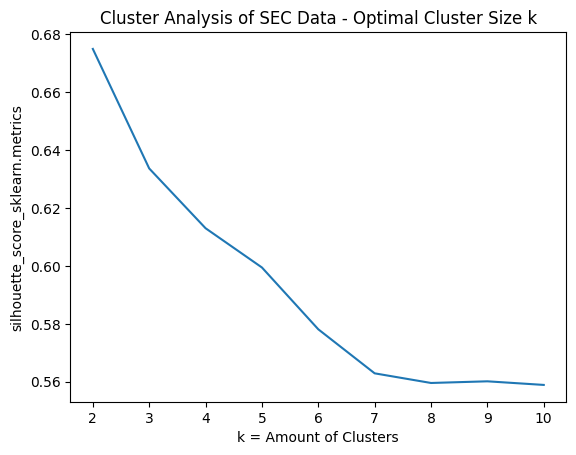

In [4]:
ys = silhouettes
xs = [x for x in range(2, 11)]

plt.plot(xs, ys)
plt.title("Cluster Analysis of SEC Data - Optimal Cluster Size k")
plt.xlabel("k = Amount of Clusters")
plt.ylabel("silhouette_score_sklearn.metrics")
plt.show()


Clusteranalyse durchführen mit k = 3


In [5]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=30,
    random_state=42
)

feature_cols = df.columns

df["kmeans"] = kmeans.fit_predict(X)

cluster_centers = (
    pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
      .assign(cluster=lambda d: d.index)
)

cluster_centers
#cluster_centers.to_csv('out.csv', index=False)


,Unnamed: 0,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,direct_ownership,transaction_month,month_sin,month_cos,filing_count_reportingOwner.name,high_frequency_trader,trades_14d,high_price,high_change_in_holdings,boxcox_amounts_shares,boxcox_amounts.pricePerShare,cluster
0,210779.641073,0.677068,0.372219,0.189423,0.063545,0.724803,6.535834,0.040908,-0.078622,0.004819,0.358491,0.010328,0.561831,0.550717,12.766085,3.045332,0
1,109005.912164,0.661525,0.396188,0.159240,0.058534,0.720715,6.843456,-0.025018,0.026307,-0.075346,0.395391,-0.076532,0.590262,0.573408,12.396910,3.121159,1
2,34576.201407,0.670260,0.414205,0.173353,0.061553,0.747582,6.524830,0.004546,-0.053362,0.064464,0.364022,0.059229,0.477609,0.567913,11.781152,2.828859,2


In [6]:
df.groupby("kmeans").size()

kmeans
0    52813
1    42604
2    45967
dtype: int64

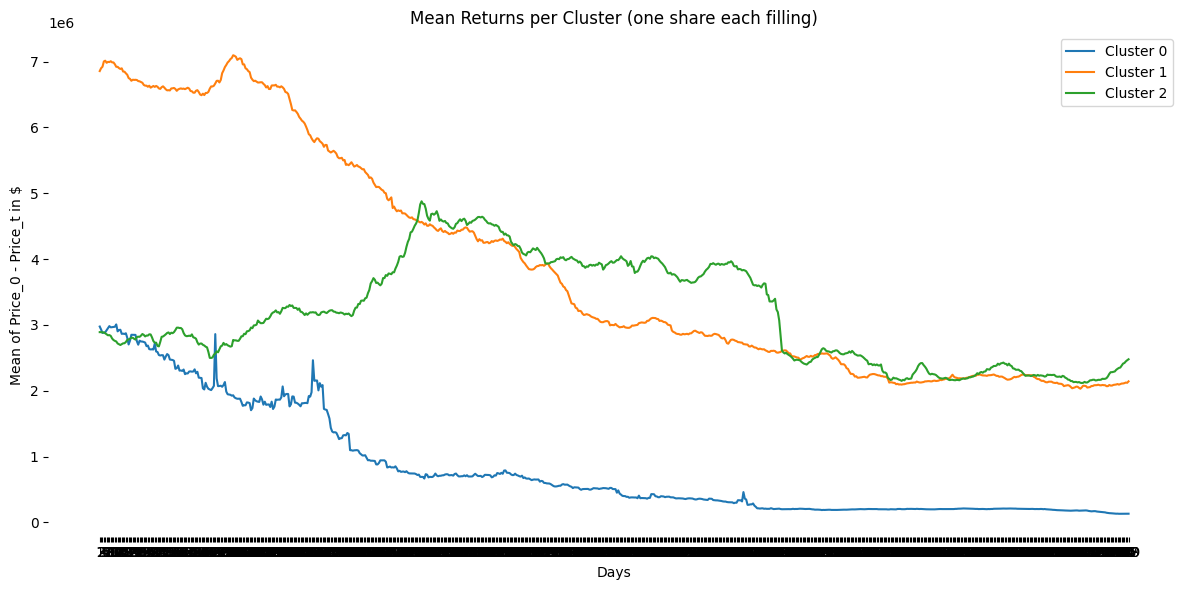

In [10]:
# Mean Returns for each cluster one share each filling
day_cols = [str(i) for i in range(1, 750)]
return_df = df_full[day_cols].copy()
return_df['kmeans'] = df['kmeans']


x_0 = df['boxcox_amounts.pricePerShare'].to_numpy()[:, None]
Xt = return_df[day_cols].to_numpy()
return_matrix = Xt - x_0
return_df = pd.DataFrame(return_matrix, columns=day_cols)
return_df['kmeans'] = df['kmeans']

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for cluster in sorted(return_df['kmeans'].unique()):
    cluster_mean = return_df[return_df['kmeans'] == cluster].mean().iloc[:-1]
    ax.plot(cluster_mean, label=f'Cluster {cluster}')

ax.set_title('Mean Returns per Cluster (one share each filling)')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of Price_0 - Price_t in $')
ax.legend()

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.show()



In [ ]:
n = df_full['amounts.shares'].to_numpy()[:, None]
x_0 = df_full['0'].to_numpy()[:, None]
Xt = df_full[day_cols].to_numpy()
return_matrix = (Xt - x_0) * n
return_df_full = pd.DataFrame(return_matrix, columns=day_cols)
return_df_full['kmeans'] = df_full['kmeans']

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for cluster in sorted(return_df_full['kmeans'].unique()):
    cluster_mean = return_df_full[return_df_full['kmeans'] == cluster].mean().iloc[:-1]
    ax.plot(cluster_mean, label=f'Cluster {cluster}')

ax.set_title('Total Mean Returns per Cluster')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of return times the amount of shares in $')
ax.legend()

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.show()

KeyError: 'amounts.shares'


Visualisierung der Cluster

Performance pro cluster vergleichen

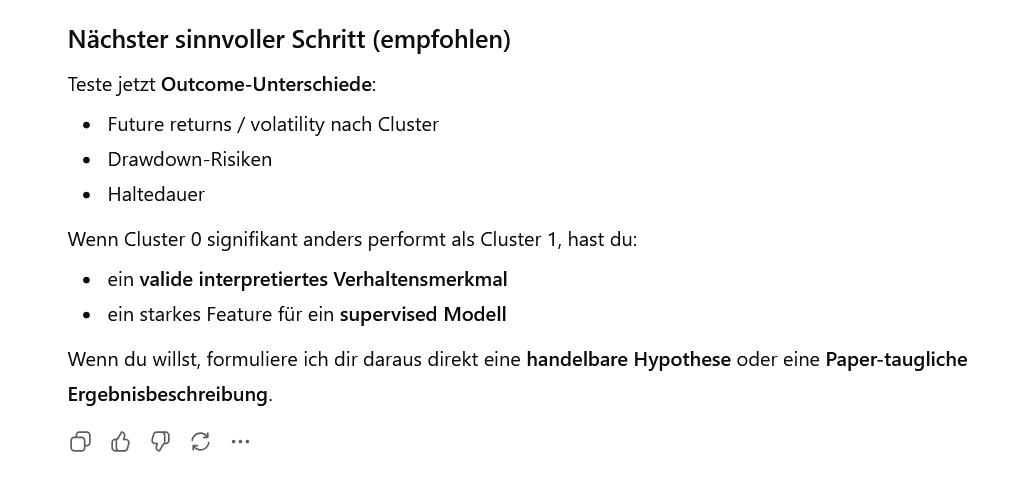

Alternative cluster Algos

preisrohdaten, bzw demeant usw und standardized_relevant_data_uncleaned

erkenntnisse auf targetengeneering anwenden

In [ ]:
corr_matrix = standardized_relevant_data_uncleaned.corr(numeric_only=False).abs()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

In [ ]:
# covariance matrix on absolute price, return per stock, absolute return weighted with amount of shares,  demeaned, percent
def plot_heatmap(df, ax, plt_title = "Return Xt - x_0"):
    corr_matrix = df.corr(numeric_only=False).abs()
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=ax)
    ax.set_title(plt_title)    

day_cols = [str(i) for i in range(364)]
absolute_price_df = pd.DataFrame(all_df_of_close_data[day_cols])

# return per stock: returns for one share each filling
x_0 = data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(0, 364)]
Xt = data[day_cols].to_numpy()
return_matrix = Xt - x_0
simple_return_df = pd.DataFrame(return_matrix)

# absolute return weighted with amount of shares
n = all_df_of_close_data['amounts.shares'].to_numpy()[:, None]
x_0 = all_df_of_close_data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(0, 364)]
Xt = all_df_of_close_data[day_cols].to_numpy()
return_matrix = (Xt - x_0)*n
weighted_return_df = pd.DataFrame(return_matrix)

# demeaned
# with matrix or else warning
abs_mat = all_df_of_close_data[day_cols].to_numpy(dtype=float)
row_mean = np.nanmean(abs_mat, axis=1, keepdims=True)
demean_mat = abs_mat - row_mean
demean_df = pd.DataFrame(demean_mat)

#percent
# calculate percentage since day 0
ref = all_df_of_close_data[day_cols[0]].to_numpy(dtype=float)[:, None]
ref = np.where(ref == 0, np.nan, ref)
percent_mat = (abs_mat - ref) / ref
percent_df = pd.DataFrame(percent_mat)

# plot absolute, demeaned and percentage in one pic
fig, axs = plt.subplots(2, 3, figsize=(12, 12), sharex=True)

plot_heatmap(absolute_price_df,  axs[0, 0], "Covariance of Absolute Price")
plot_heatmap(simple_return_df,   axs[0, 1], "Covariance of Simple Return Xt - x_0")
plot_heatmap(weighted_return_df, axs[0, 2], "Covariance of Weighted Return (Xt - x_0)*n")
plot_heatmap(demean_df,          axs[1, 0], "Covariance of Demeaned Price")
plot_heatmap(percent_df,         axs[1, 1], "Covariance of Percent (abs_mat - ref)/ref")


plt.tight_layout()
#plt.savefig('exports/descriptive_random_state_69.png', dpi=500)
plt.show()


## SNIPPET 4.1 BASE CLUSTERING  

MACHINE LEARNING FOR
ASSET MANAGERS
Marcos M. López de Prado

In [ ]:
x, silh=((1-corr0.fillna(0))/2.)**.5, pd.Series()

In [ ]:
def clusterKMeansBase(corr0, maxNumClusters=10, n_init=10):
    x, silh=((1-corr0.fillna(0))/2.)**.5, pd.Series()  # observation matrix
    for init in range(n_init):
        for i in xrange(2, maxNumClusters+1):
            kmeans_=KMeans(n_clusters=i, n_jobs=1, n_init=1)
            kmeans_=kmeans_.fit(x)
            silh_=silhouette_samples(x, kmeans_.labels_)
            stat=(silh_.mean()/silh_.std(), silh.mean()/silh.std())
            if np.isnan(stat[1]) or stat[0]>stat[1]:
                silh, kmeans=silh_, kmeans_
    newIdx=np.argsort(kmeans.labels_)
    corr1=corr0.iloc[newIdx]  # reorder rows

    corr1=corr1.iloc[:,newIdx]  # reorder columns
    clstrs={i:corr0.columns[np.where(kmeans.labels_==i)[0]].tolist()\
            for i in np.unique(kmeans.labels_)}  # cluster members
    silh=pd.Series(silh, index=x.index)
    return corr1, clstrs, silh
